In [1]:
from operator import eq, mul, sub, mod, floordiv, pow

class FunctionCounter():
    def __init__(self):
        self.counter = {}
            
    def __call__(self, operator, a, b):
        self.counter[operator] = self.counter.get(operator, 0) + 1
        return operator(a, b)

def counter_decorator(func):
    def wrapper(*args, **kwargs):
        counter = FunctionCounter()
        result = func(func, counter, *args, **kwargs)
        return counter.counter, result
    return wrapper


n = 22910264207983771291378056494620596261346852817449992055450163409041710702771544451151755290573065755883547261034483482566257691525062462594497892399271648399200557737574449177691016178537501628628813941472397870536409599979340655096663049958140066310957126863774839429364735831161742643323065623269613139263506725349791604681730541179340298300026292493730589797764864171491366174943455462484440232999779266915369787208040452020196096697684935083569014983000930136486279183543611872470883439587083563565665450913256188038324041062621534105553214172441853538664870835246346528688211813384644086615748627869680393651031
from sys import setrecursionlimit
setrecursionlimit(2 ** 31 - 1)
@counter_decorator
def modular_exponentiation_minus(self, counter, base, g):
    return 1 if counter(eq, g, 0) else counter(mod, counter(mul, base, self(self, counter, base, counter(sub, g, 1))), n)
counter_b = modular_exponentiation_minus(2, 65537)
b = counter_b[-1]
print(counter_b)

({<built-in function eq>: 65538, <built-in function sub>: 65537, <built-in function mul>: 65537, <built-in function mod>: 65537}, 4165456238165848420160292375025951448763304667152192296665303714954836041682652489179580909769474541844884569262113711315600279437163426712587513791305435121976948547635197097971331925727919985488360842211930286547315537312078364562501293337266909414728206100245596468218378107692159715770643758430733450279354887048838114332027126254595567641954366952062267411591407557459494228817825846881868278667942425644169015793887808016912667830645103966616972224728713494682214318006725657955055407233786003052302683814297946033775622712665041418212826713364754313068068385913610150423260970639272081190447060728070743692853)


In [2]:
d = 40585954110607990096113529136601480475797940279627448275596441274238103858763390310492069964074231872958478981431916815324816790302573384610543743344300751928638551556104086997115018666222194166406843441185061763115143423678249691879740911243115517931887673053149501163453405404548244821853425070747853662335136530195027112703832077759089025007240673600903097399742564976475595809853952960906988138460916199877588630503802487829847933068222692814977103604770176625626706062658337112489840263933926599829151790292984602006268094803638320532289829882988912477937999931095206226710739264457351880786570422922717936673
@counter_decorator
def modular_exponentiation(self, counter, base, g):        
    return \
        1 if counter(eq, g, 0) else \
        counter(mod, counter(mul, base, self(self, counter, base, counter(sub, g, 1))), n) if counter(eq, counter(mod, g, 2), 1) else \
        counter(mod, counter(pow, self(self, counter, base, counter(floordiv, g, 2)), 2), n)
print(modular_exponentiation(b, d))

({<built-in function eq>: 6169, <built-in function mod>: 6168, <built-in function sub>: 1046, <built-in function floordiv>: 2038, <built-in function mul>: 1046, <built-in function pow>: 2038}, 2)


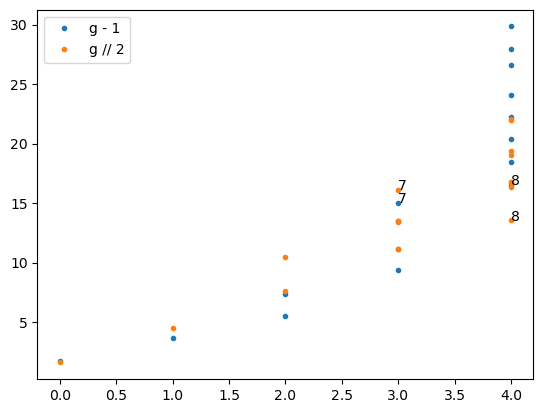

In [3]:
def plot_speed(max_exponent, effect, stmt_label_pairs):
    from matplotlib.pyplot import subplots, show
    x = [g.bit_length() for g in range(2 ** max_exponent)]
    modular_exponentiation_y = {
        label: [effect(lambda: stmt(g)) for g in range(2 ** max_exponent)]
        for label, stmt in stmt_label_pairs}
    fig, ax = subplots()
    for label, modular_exponentiation_y_value in modular_exponentiation_y.items():
        ax.plot(x, modular_exponentiation_y_value, label=label, linestyle='', marker='.')
    ax.legend()

    # label a few points
    for i in range(max_exponent // 4 * 3, max_exponent):
        for offset in range(2):
            for m_e in modular_exponentiation_y.values():
                g = 2 ** i - offset
                ax.annotate(f"{g}", xy=(x[g], m_e[g]))
    show()

from timeit import timeit
plot_speed(4, timeit, (
    # ('**', lambda g: 2 ** g % n),
    ('g - 1', lambda g: modular_exponentiation_minus(2, g)),
    ('g // 2', lambda g: modular_exponentiation(2, g))))

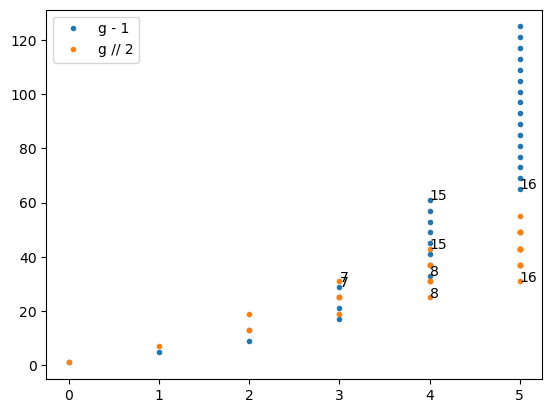

In [4]:
plot_speed(
    5, 
    lambda stmt: sum(stmt()[0].values()), 
    (# ('**', lambda g: 2 ** g % n),
    ('g - 1', lambda g: modular_exponentiation_minus(2, g)),
    ('g // 2', lambda g: modular_exponentiation(2, g))))